In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('titanic.csv')
data.head()
data.columns = data.columns.str.lower()

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   name         891 non-null    object 
 4   sex          891 non-null    object 
 5   age          714 non-null    float64
 6   sibsp        891 non-null    int64  
 7   parch        891 non-null    int64  
 8   ticket       891 non-null    object 
 9   fare         891 non-null    float64
 10  cabin        204 non-null    object 
 11  embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
data.describe()

,passengerid,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
print(data.isnull().sum())
print('Duplicates:', data.duplicated().sum())
print(data['survived'].value_counts())

passengerid      0
survived         0
pclass           0
name             0
sex              0
age            177
sibsp            0
parch            0
ticket           0
fare             0
cabin          687
embarked         2
dtype: int64
Duplicates: 0
survived
0    549
1    342
Name: count, dtype: int64


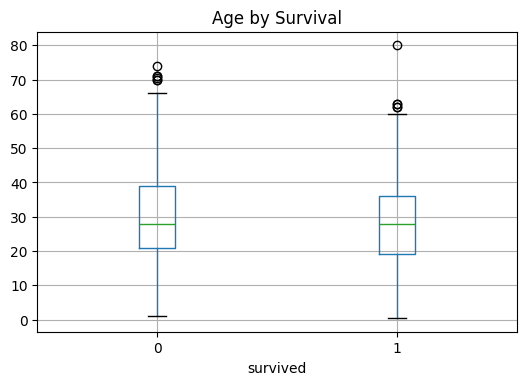

In [6]:
data.boxplot(column='age', by='survived', figsize=(6,4))
plt.title('Age by Survival')
plt.suptitle('')
plt.show()

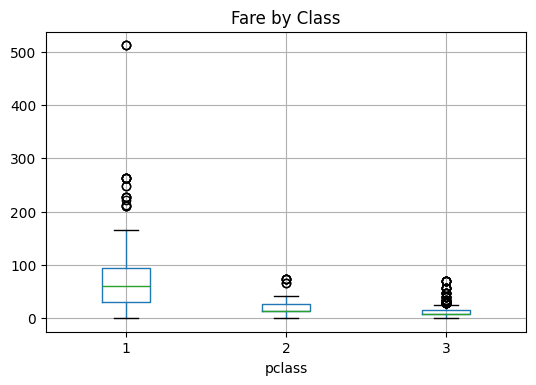

In [7]:
data.boxplot(column='fare', by='pclass', figsize=(6,4))
plt.title('Fare by Class')
plt.suptitle('')
plt.show()

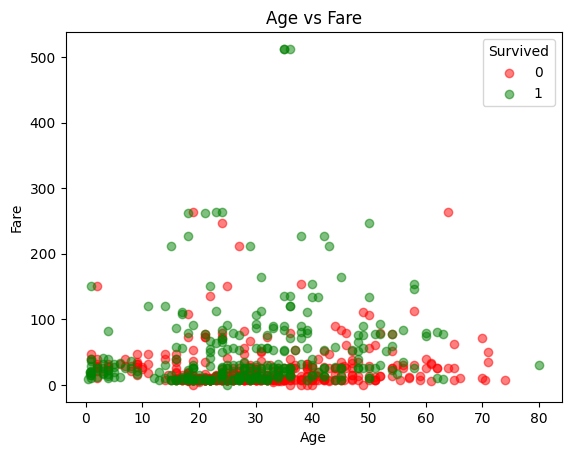

In [8]:
for val, color in [(0,'red'), (1,'green')]:
    g = data[data['survived'] == val]
    plt.scatter(g['age'], g['fare'], c=color, alpha=0.5, label=str(val))
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Age vs Fare')
plt.legend(title='Survived')
plt.show()

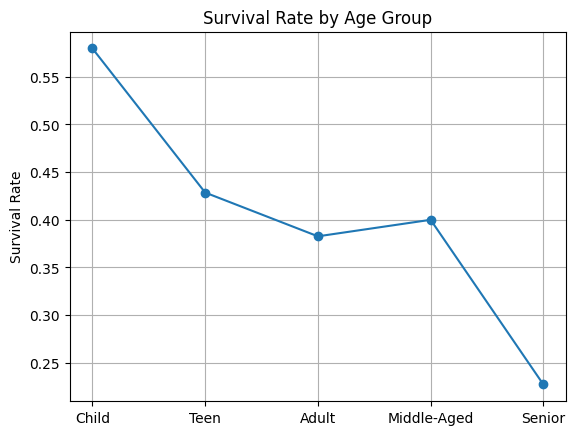

In [9]:
data['age_group'] = pd.cut(data['age'], bins=[0,12,18,35,60,80],
                            labels=['Child','Teen','Adult','Middle-Aged','Senior'])
rate = data.groupby('age_group', observed=True)['survived'].mean()
plt.plot(rate.index, rate.values, marker='o')
plt.title('Survival Rate by Age Group')
plt.ylabel('Survival Rate')
plt.grid(True)
plt.show()

In [10]:
print('''
Insights:
- Survivors are slightly younger on average (Box Plot)
- Class 1 has the highest and most spread fares, with many outliers
- Higher fare = more likely to survive (Scatter Plot)
- Children have the highest survival rate (Line Plot)

Preprocessing Steps:
1. Fill missing age with median per pclass and sex
2. Fill missing fare with median
3. Drop duplicate rows
4. Cap fare outliers using IQR method
5. Handle class imbalance (SMOTE or class_weight)
6. Encode sex and embarked columns
7. Standardize age and fare
''')


Insights:
- Survivors are slightly younger on average (Box Plot)
- Class 1 has the highest and most spread fares, with many outliers
- Higher fare = more likely to survive (Scatter Plot)
- Children have the highest survival rate (Line Plot)

Preprocessing Steps:
1. Fill missing age with median per pclass and sex
2. Fill missing fare with median
3. Drop duplicate rows
4. Cap fare outliers using IQR method
5. Handle class imbalance (SMOTE or class_weight)
6. Encode sex and embarked columns
7. Standardize age and fare

